## Filter out background and low-quality cells

In [84]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
from scipy.sparse import csr_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
from pathlib import Path

In [73]:
import sys, scanpy, umap, numpy, pandas

print("Python:", sys.version)
print("Scanpy:", scanpy.__version__)
print("UMAP:", umap.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)

Python: 3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]
Scanpy: 1.9.6
UMAP: 0.5.5
NumPy: 1.26.0
Pandas: 2.1.1


In [74]:
print(os.getcwd())
this_path = os.getcwd()

C:\Users\Chenxi Zhou\Desktop\Neural Crest\SingleCrest\merscope\result\analysis\2025MAY\Tutorial_Github\tutorial


In [75]:
## import count_matrix and meta data into h5ad file
## For tutorial here as an example, we selected 4 sections from stage 22 embryos and 54 references genes   

adata = sq.read.vizgen(
    path=this_path,
    counts_file="data\\cell_by_gene_filtered_subset.csv",
    meta_file="data\\cell_metadata_anno_subset.csv",
    # transformation_file="micron_to_mosaic_pixel_transform.csv",
)

## filtered by selected gene

#gene_df = pd.read_csv("selected_genes_for_cluster.csv")
#gene_list = gene_df.iloc[:, 0].tolist()
#adata = adata[:, adata.var_names.isin(gene_list)].copy()

print(adata.var_names.tolist())
adata.write_h5ad("MER02_R1_raw_stage22_subset.h5ad")

['ACTC1.L', 'CD44.L', 'CDH1.S', 'CDX4.L', 'CHRD.1.S', 'DLX2.L', 'DLX3.L', 'EGR2.L', 'ELAVL3.L', 'EPHA2.L', 'EPHA4.L', 'EYA1.L', 'FOXC2.L', 'GATA2.L', 'GBX2.2.L', 'HNF1B.L', 'HOXA3.S', 'HOXC10.L', 'HOXD3.L', 'KRT12.4.L', 'MAFB.S', 'MSX1.L', 'MSX2.L', 'MYL1.L', 'MYOD1.S', 'NOG.L', 'OLIG4.L', 'OTX2.S', 'PAX3.S', 'PAX6.S', 'PAX7.L', 'PITX1.L', 'RAX.L', 'SIX1.L', 'SNAI1.S', 'SNAI2.L', 'SOX10.L', 'SOX17A.S', 'SOX2.L', 'SOX3.S', 'SOX8.L', 'SOX9.S', 'TFAP2A.L', 'TFAP2C.L', 'TP63.L', 'VENTX2.1.L', 'TBXT.S', 'ZIC1.S', 'OLIG3.S', 'EYA2.S', 'HOXB6.S', 'HOXB9.S', 'HOXC9.S', 'HOXD11.L']


In [76]:
adata

AnnData object with n_obs × n_vars = 6738 × 54
    obs: 'crop', 'stage', 'embryo_ID', 'section_level', 'uniqueID', 'fov', 'volume', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity'
    uns: 'spatial'
    obsm: 'blank_genes', 'spatial'

## reduce background

In [77]:
## Reduce background
## Remove the single trnanscript event (where only one transcript of a gene is detected in a cell)

adata.layers["raw_counts"]=adata.X.copy()
adata.layers["raw_counts_bg_removeby1"] =adata.layers["raw_counts"].copy()

from scipy import sparse

print("Non-zero count before:", adata.X.nnz)
adata.X.data[adata.X.data <= 1] = 0
adata.X.eliminate_zeros()
print("Non-zero count after:", adata.X.nnz)

adata.layers["raw_counts_bg_removeby1"] = adata.X

#adata.to_df("raw_counts")
adata.to_df("raw_counts_bg_removeby1")





Non-zero count before: 136004
Non-zero count after: 79334


,ACTC1.L,CD44.L,CDH1.S,CDX4.L,CHRD.1.S,DLX2.L,DLX3.L,EGR2.L,ELAVL3.L,EPHA2.L,...,TP63.L,VENTX2.1.L,TBXT.S,ZIC1.S,OLIG3.S,EYA2.S,HOXB6.S,HOXB9.S,HOXC9.S,HOXD11.L
2685806100002100001,0.0,0.0,32.0,0.0,0.0,0.0,6.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100002100002,0.0,2.0,95.0,0.0,0.0,0.0,7.0,0.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100002100003,0.0,0.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100002100004,2.0,0.0,16.0,0.0,0.0,0.0,9.0,0.0,0.0,3.0,...,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
2685806100002100005,0.0,0.0,44.0,0.0,0.0,0.0,7.0,0.0,0.0,23.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2685806100125100271,0.0,0.0,23.0,0.0,0.0,0.0,4.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100125100272,3.0,0.0,30.0,0.0,0.0,0.0,8.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100150100007,0.0,0.0,25.0,0.0,0.0,0.0,10.0,0.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100150100008,0.0,0.0,33.0,0.0,0.0,0.0,6.0,0.0,0.0,2.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
adata.to_df("raw_counts")

,ACTC1.L,CD44.L,CDH1.S,CDX4.L,CHRD.1.S,DLX2.L,DLX3.L,EGR2.L,ELAVL3.L,EPHA2.L,...,TP63.L,VENTX2.1.L,TBXT.S,ZIC1.S,OLIG3.S,EYA2.S,HOXB6.S,HOXB9.S,HOXC9.S,HOXD11.L
2685806100002100001,0.0,0.0,32.0,0.0,0.0,0.0,6.0,0.0,0.0,3.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2685806100002100002,1.0,2.0,95.0,0.0,0.0,1.0,7.0,1.0,0.0,6.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2685806100002100003,0.0,0.0,24.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2685806100002100004,2.0,0.0,16.0,0.0,0.0,0.0,9.0,1.0,0.0,3.0,...,2.0,1.0,0.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0
2685806100002100005,1.0,1.0,44.0,0.0,0.0,1.0,7.0,0.0,0.0,23.0,...,1.0,0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2685806100125100271,1.0,0.0,23.0,1.0,0.0,0.0,4.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2685806100125100272,3.0,0.0,30.0,0.0,0.0,0.0,8.0,2.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2685806100150100007,1.0,1.0,25.0,0.0,0.0,0.0,10.0,0.0,0.0,6.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2685806100150100008,0.0,0.0,33.0,0.0,0.0,0.0,6.0,0.0,0.0,2.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## remove low quality cells

C:\Users\Chenxi Zhou\anaconda3\envs\scanpy\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Chenxi Zhou\anaconda3\envs\scanpy\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Chenxi Zhou\anaconda3\envs\scanpy\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Chenxi Zhou\anaconda3\envs\scanpy\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future

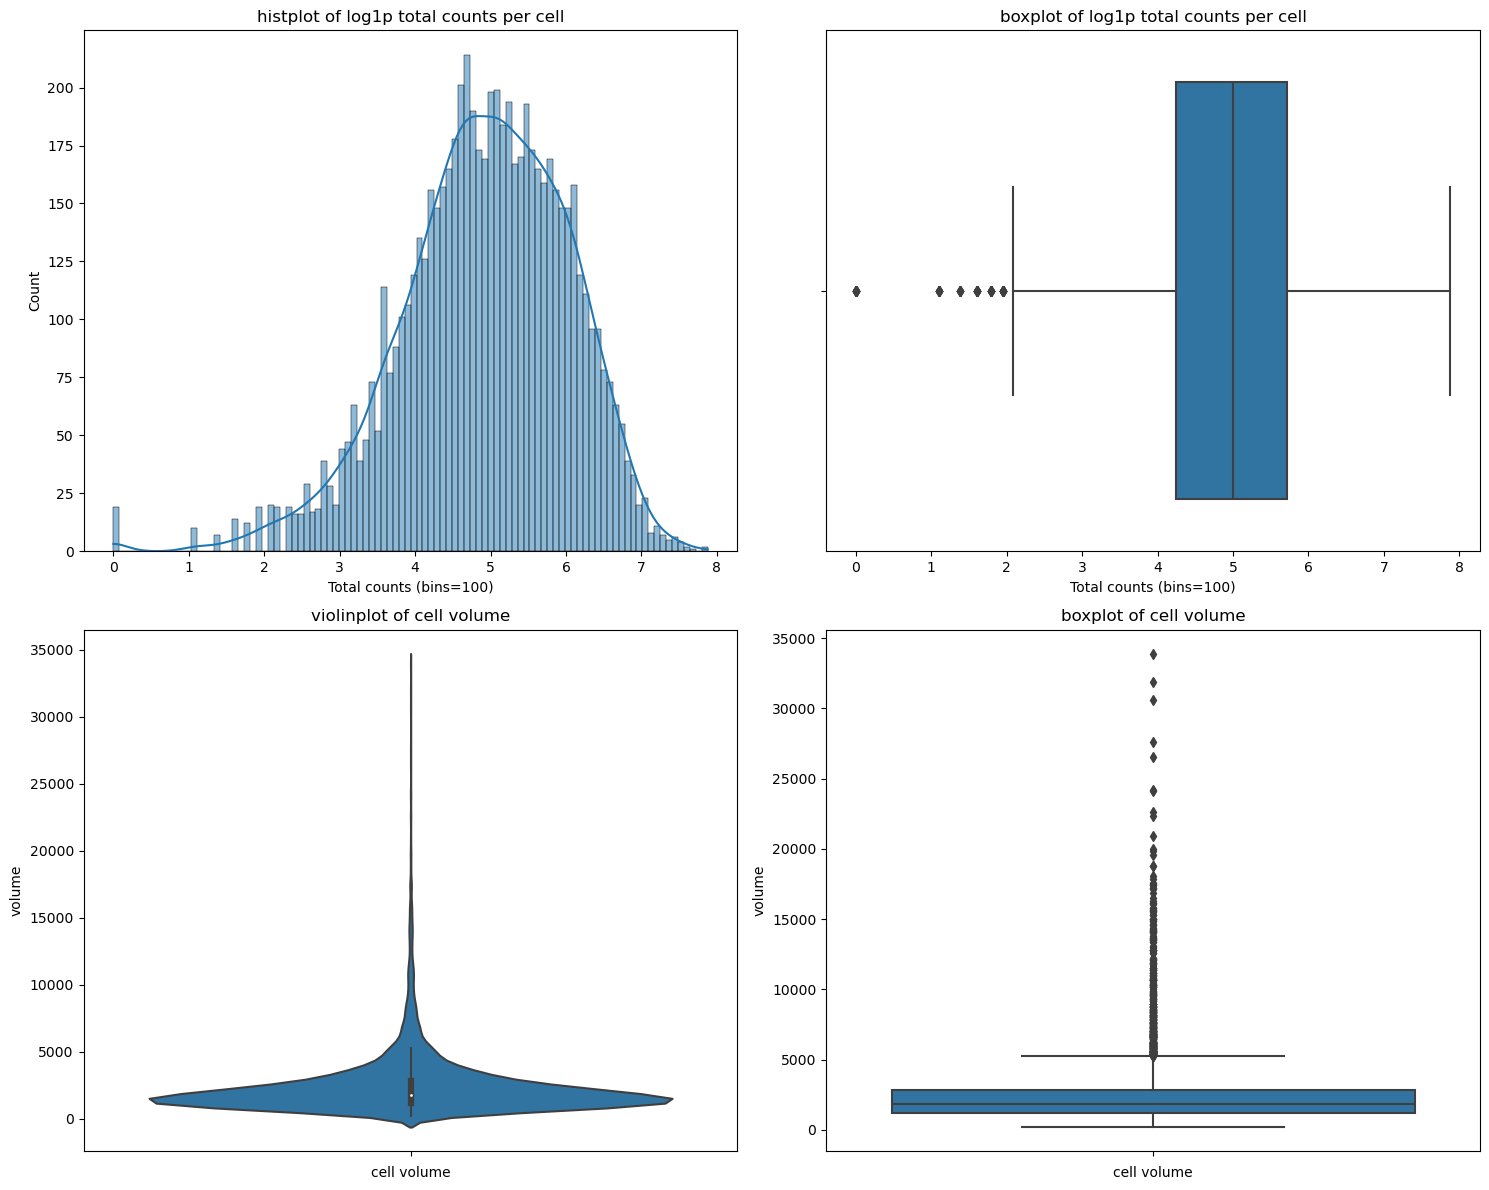

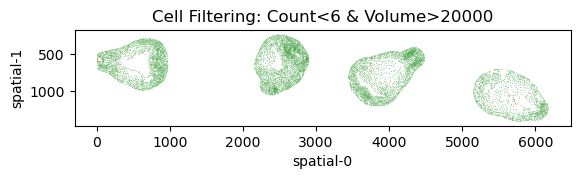

In [79]:
## Qaulity control of the data based on count and volume distribution

adata.X = adata.layers["raw_counts_bg_removeby1"]
sc.pp.calculate_qc_metrics(adata,percent_top=(1,5,10,15), inplace=True)


fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.histplot(
    data=adata.obs,
    x="log1p_total_counts",
    kde=True,
    ax=axes[0,0],
    bins=100, 
)
axes[0,0].set_title("histplot of log1p total counts per cell")
axes[0,0].set_xlabel("Total counts (bins=100)")
#ax1.axvline(x=3, color="red", linestyle="--")


sns.boxplot(
    data=adata.obs,
    x="log1p_total_counts",
    ax=axes[0,1],
)
axes[0,1].set_title("boxplot of log1p total counts per cell")
axes[0,1].set_xlabel("Total counts (bins=100)")


sns.violinplot(
    data=adata.obs,
    y="volume",
    ax=axes[1,0],
)
axes[1,0].set_title("violinplot of cell volume")
axes[1,0].set_xlabel("cell volume")


sns.boxplot(
    data=adata.obs,
    y="volume",
    ax=axes[1,1],
)
axes[1,1].set_title("boxplot of cell volume")
axes[1,1].set_xlabel("cell volume")


plt.tight_layout()
plt.savefig("qc_metrics_combined.png", dpi=300)
plt.show()


## draw the binary plot of filtered cells 

adata_df = sc.get.obs_df(adata,keys=["total_counts", "volume", "log1p_total_counts"], obsm_keys=[("spatial",0),("spatial",1)])

count_threshold = 6  ## set the count cutoff threshold
volume_threshold = 20000  ## set the volume cutoff threshold

# kept cells color: green
adata_df["dot_color"] = "green"  

# only count_threshold < 6: red
adata_df.loc[adata_df["total_counts"] < count_threshold, "dot_color"] = "red"

# only volume_threshold > 20000: blue  
adata_df.loc[adata_df["volume"] > volume_threshold, "dot_color"] = "blue"

# both count_threshold < 6 and volume_threshold > 20000: orange
adata_df.loc[(adata_df["total_counts"] < count_threshold) & (adata_df["volume"] > volume_threshold), "dot_color"] = "orange"

fig = adata_df.plot.scatter(x="spatial-0", y="spatial-1", c=adata_df["dot_color"], s=1, marker='.', linewidths=0)
fig.invert_yaxis()
fig.set_aspect('equal', adjustable='box')
plt.title(f"Cell Filtering: Count<{count_threshold} & Volume>{volume_threshold}")
plt.savefig(f"cell_filtering_count{count_threshold}_volume{volume_threshold}.png", dpi=300)

In [80]:
## filtering low quality cells

# filtered out by volume
adata.obs["volume_filter"]=np.where(adata.obs["volume"] <= 20000, "keep", "remove")
adata_filtered = adata[adata.obs["volume_filter"] == "keep"].copy()
print(adata_filtered.obs["volume_filter"].unique())

# filtered out by minimum total_counts
sc.pp.filter_cells(adata_filtered, min_counts=6)

adata_filtered.write_h5ad("MER02_R1_filtered_stage22_subset.h5ad")



['keep']


In [81]:
adata_filtered

AnnData object with n_obs × n_vars = 6666 × 54
    obs: 'crop', 'stage', 'embryo_ID', 'section_level', 'uniqueID', 'fov', 'volume', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_1_genes', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'volume_filter', 'n_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'spatial'
    obsm: 'blank_genes', 'spatial'
    layers: 'raw_counts', 'raw_counts_bg_removeby1'